# تشخیص چهره با PCA از صفر — بخش اول

در این نوت‌بوک از کلاس آماده‌ی `PCA` استفاده نمی‌کنیم. هر مرحله را با فرمول و دستورهای ساده‌ی NumPy می‌سازیم:

1. آماده‌کردن داده‌ها
2. میانگین و مرکزسازی
3. واریانس و کوواریانس
4. مقدارهای ویژه و بردارهای ویژه

> تصویرکردن داده‌ها روی مؤلفه‌ها و تشخیص چهره، مرحله‌ی بعدی پروژه است.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# sklearn را فقط برای گرفتن دیتاست استفاده می‌کنیم، نه برای PCA.
data = fetch_olivetti_faces()
images = data.images
labels = data.target

print('images:', images.shape)  # 400 images, each 64x64
print('labels:', labels.shape)

images: (400, 64, 64)
labels: (400,)


## ۱. آماده‌کردن داده‌ها

هر تصویر `64×64` را باز می‌کنیم تا یک ردیف با `4096` عدد شود. پس هر ردیف یک تصویر و هر ستون یک پیکسل است. سپس از ۱۰ تصویر هر شخص، ۸ تصویر را برای آموزش و ۲ تصویر را برای آزمون می‌گذاریم.

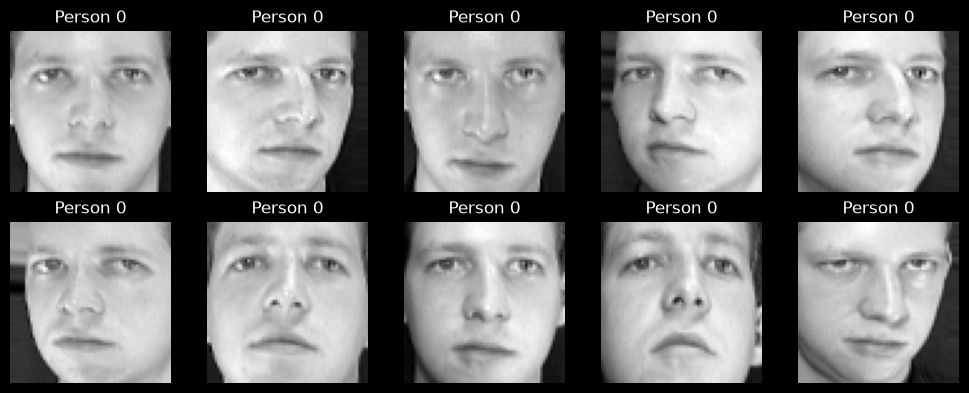

X: (400, 4096)
number of persons: 40
images per person: [10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10]


In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f'Person {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

X = images.reshape(400, 64 * 64).astype(float)
print('X:', X.shape)
print('number of persons:', len(np.unique(labels)))
print('images per person:', np.bincount(labels))

In [11]:
train_indices = []
test_indices = []

for person in np.unique(labels):
    indices = np.where(labels == person)[0]
    train_indices.extend(indices[:8])
    test_indices.extend(indices[8:])

X_train = X[train_indices]
X_test = X[test_indices]
y_train = labels[train_indices]
y_test = labels[test_indices]

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('8 train images per person:', np.all(np.bincount(y_train) == 8))
print('2 test images per person :', np.all(np.bincount(y_test) == 2))

X_train: (320, 4096)
X_test : (80, 4096)
8 train images per person: True
2 test images per person : True


## ۲. میانگین و مرکزسازی

میانگین هر پیکسل را فقط از تصویرهای آموزشی حساب می‌کنیم:

$$\mu_j = \frac{1}{n} \sum_{i=1}^{n} X_{ij}$$

بعد چهره‌ی میانگین را از همه‌ی تصویرها کم می‌کنیم:

$$X_{centered} = X - \mu$$

largest absolute mean after centering: 2.286365541337432e-16


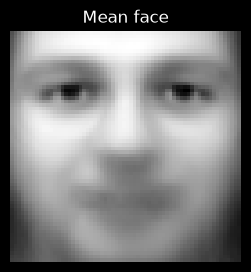

In [12]:
n_train = X_train.shape[0]

# mean = sum / count
mean_face = np.sum(X_train, axis=0) / n_train
X_train_centered = X_train - mean_face
X_test_centered = X_test - mean_face  # همان میانگین آموزش

column_means = np.sum(X_train_centered, axis=0) / n_train
print('largest absolute mean after centering:', np.max(np.abs(column_means)))

plt.figure(figsize=(3, 3))
plt.imshow(mean_face.reshape(64, 64), cmap='gray')
plt.title('Mean face')
plt.axis('off')
plt.show()

## ۳. واریانس

واریانس می‌گوید عددها چقدر دورِ میانگین پخش شده‌اند. برای واریانس نمونه بر `n-1` تقسیم می‌کنیم:

$$Var(x) = \frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}$$

a               = [1. 2. 3. 4. 5.]
mean            = 3.0
a - mean        = [-2. -1.  0.  1.  2.]
sample variance = 2.5
NumPy check     = 2.5
pixel variances shape: (4096,)


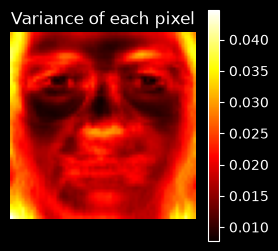

In [13]:
# اول یک مثال خیلی کوچک
a = np.array([1, 2, 3, 4, 5], dtype=float)
a_mean = np.sum(a) / len(a)
a_centered = a - a_mean
a_variance = np.sum(a_centered ** 2) / (len(a) - 1)

print('a               =', a)
print('mean            =', a_mean)
print('a - mean        =', a_centered)
print('sample variance =', a_variance)
print('NumPy check     =', np.var(a, ddof=1))

# حالا همان فرمول برای همه‌ی پیکسل‌ها
pixel_variances = np.sum(X_train_centered ** 2, axis=0) / (n_train - 1)
print('pixel variances shape:', pixel_variances.shape)

plt.figure(figsize=(3, 3))
plt.imshow(pixel_variances.reshape(64, 64), cmap='hot')
plt.title('Variance of each pixel')
plt.colorbar()
plt.axis('off')
plt.show()

## ۴. کوواریانس

کوواریانس می‌گوید دو ویژگی با هم تغییر می‌کنند یا خلاف جهت هم:

$$Cov(x,y) = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{n-1}$$

برای داده‌ی مرکز‌شده، ماتریس کوواریانس همه‌ی پیکسل‌ها برابر است با:

$$C = \frac{X_{centered}^{T}X_{centered}}{n-1}$$

In [14]:
# مثال کوچک کوواریانس
b = np.array([2, 4, 6, 8, 10], dtype=float)
c = np.array([5, 4, 3, 2, 1], dtype=float)
b_centered = b - np.sum(b) / len(b)
c_centered = c - np.sum(c) / len(c)

cov_a_b = np.sum(a_centered * b_centered) / (len(a) - 1)
cov_a_c = np.sum(a_centered * c_centered) / (len(a) - 1)
print('cov(a, b) =', cov_a_b, '-> same direction')
print('cov(a, c) =', cov_a_c, '-> opposite directions')

# یک ماتریس کوواریانس کوچک برای 5 پیکسل تصویر
coordinates = [(16, 16), (16, 48), (32, 32), (48, 16), (48, 48)]
columns = [row * 64 + col for row, col in coordinates]
five_pixels = X_train_centered[:, columns]
covariance_5_pixels = (five_pixels.T @ five_pixels) / (n_train - 1)

print('\n5x5 covariance matrix:')
print(np.round(covariance_5_pixels, 4))
print('diagonal = variances:',
      np.allclose(np.diag(covariance_5_pixels), pixel_variances[columns]))

cov(a, b) = 5.0 -> same direction
cov(a, c) = -2.5 -> opposite directions

5x5 covariance matrix:
[[0.0081 0.0036 0.0028 0.0009 0.0013]
 [0.0036 0.0081 0.0025 0.002  0.0033]
 [0.0028 0.0025 0.0236 0.004  0.0052]
 [0.0009 0.002  0.004  0.0146 0.009 ]
 [0.0013 0.0033 0.0052 0.009  0.0156]]
diagonal = variances: True


## ۵. ساختن ماتریس کوچک برای Eigenfaces

ماتریس مستقیم کوواریانس پیکسل‌ها `4096×4096` است و تجزیه‌ی ویژه‌ی آن سنگین می‌شود. چون فقط ۳۲۰ تصویر آموزشی داریم، این ماتریس کوچک‌تر را می‌سازیم:

$$L = \frac{X_{centered}X_{centered}^{T}}{n-1}$$

شکل `L` برابر `320×320` است. مقدارهای ویژه‌ی غیرصفر آن با ماتریس بزرگ یکسان‌اند. بعد بردارهای ویژه را به فضای ۴۰۹۶ پیکسل برمی‌گردانیم.

In [8]:
small_covariance = (X_train_centered @ X_train_centered.T) / (n_train - 1)

print('small covariance:', small_covariance.shape)
print('is symmetric:', np.allclose(small_covariance, small_covariance.T))

small covariance: (320, 320)
is symmetric: True


## ۶. مقدار ویژه و بردار ویژه

$$L v = \lambda v$$

- $v$ بردار ویژه است: یک جهت مهم در داده‌ها.
- $\lambda$ مقدار ویژه است: میزان واریانس در آن جهت.

`np.linalg.eigh` فقط تجزیه‌ی ویژه‌ی ماتریس متقارن را انجام می‌دهد و PCA آماده نیست. خروجی آن صعودی است، پس نتیجه را نزولی مرتب می‌کنیم.

In [15]:
eigenvalues, sample_eigenvectors = np.linalg.eigh(small_covariance)

# بزرگ‌ترین مقدار ویژه باید اول قرار بگیرد.
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
sample_eigenvectors = sample_eigenvectors[:, order]

# صفرهای بسیار کوچک اطلاعاتی ندارند و حاصل محدودیت رتبه/خطای عددی‌اند.
useful = eigenvalues > eigenvalues[0] * 1e-10
eigenvalues = eigenvalues[useful]
sample_eigenvectors = sample_eigenvectors[:, useful]

print('eigenvalues:', eigenvalues.shape)
print('sample eigenvectors:', sample_eigenvectors.shape)
print('10 largest eigenvalues:')
print(np.round(eigenvalues[:10], 4))

eigenvalues: (319,)
sample eigenvectors: (320, 319)
10 largest eigenvalues:
[18.5006 10.1455  6.2815  4.1128  2.9456  2.6477  2.0293  1.7041  1.5749
  1.4373]


## ۷. تبدیل بردارهای ویژه به Eigenface

بردارهای فعلی ۳۲۰ عدد دارند. با فرمول زیر آن‌ها را به بردارهای ۴۰۹۶ پیکسلی تبدیل می‌کنیم:

$$u = X_{centered}^{T}v$$

بعد طول هر بردار را یک می‌کنیم. اکنون هر ستون یک بردار ویژه در فضای پیکسل‌هاست و می‌توان آن را مانند تصویر نمایش داد.

eigenfaces: (4096, 319)
length of first 5 vectors: [1. 1. 1. 1. 1.]


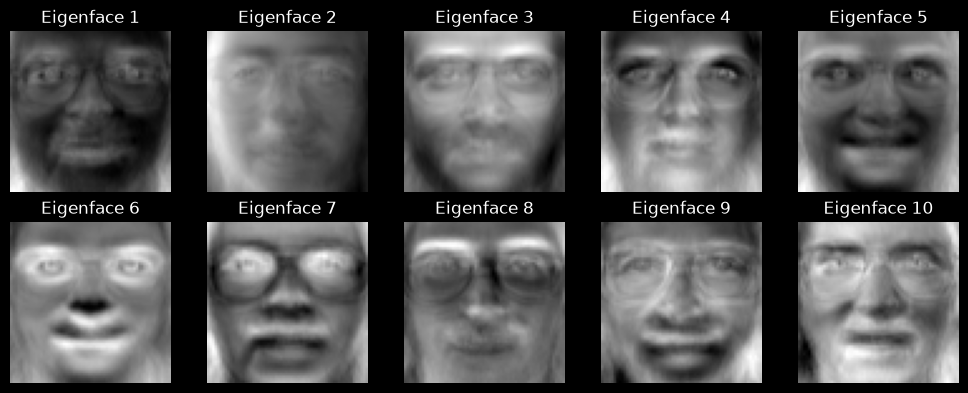

variance of first component: 23.65 %
variance of first 10 components: 65.69 %


In [16]:
eigenfaces = X_train_centered.T @ sample_eigenvectors

lengths = np.sqrt(np.sum(eigenfaces ** 2, axis=0))
eigenfaces = eigenfaces / lengths

print('eigenfaces:', eigenfaces.shape)
print('length of first 5 vectors:',
      np.round(np.sqrt(np.sum(eigenfaces[:, :5] ** 2, axis=0)), 6))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[:, i].reshape(64, 64), cmap='gray')
    ax.set_title(f'Eigenface {i + 1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

explained_ratio = eigenvalues / np.sum(eigenvalues)
print('variance of first component:', round(explained_ratio[0] * 100, 2), '%')
print('variance of first 10 components:', round(np.sum(explained_ratio[:10]) * 100, 2), '%')

## جمع‌بندی

تا اینجا بدون PCA آماده، داده را تخت و مرکز کردیم، واریانس و کوواریانس را از فرمول ساختیم، مقدارها و بردارهای ویژه را محاسبه و مرتب کردیم و Eigenfaceها را دیدیم.

مرحله‌ی بعد: انتخاب تعداد مؤلفه‌ها، تبدیل تصویرها به مختصات PCA و سپس شناسایی نزدیک‌ترین چهره.